In [1]:
from pathlib import Path
import pickle

import pandas as pd
import numpy as np
import inspect
import xarray as xr

import matplotlib.pyplot as plt
import torch
from neuralhydrology.evaluation import metrics, get_tester
from neuralhydrology.utils.config import Config
import neuralhydrology.modelzoo
from neuralhydrology.nh_run import start_run, eval_run, finetune
from neuralhydrology.evaluation.prob_metrics import run_probabilistic_evaluation

In [4]:
# This block ensures the code inside only runs when the script is executed directly
if __name__ == '__main__':

    # by default we assume that you have at least one CUDA-capable NVIDIA GPU or MacOS with Metal
    # support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        start_run(config_file=Path("1_basin.yml"))

    # fall back to CPU-only mode
    else:
        start_run(config_file=Path("1_basin.yml"), gpu=-1)

2025-11-18 03:01:57,944: Logging to d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1811_030157\output.log initialized.
2025-11-18 03:01:57,948: ### Folder structure created at d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1811_030157
2025-11-18 03:01:57,948: ### Run configurations for test_run
2025-11-18 03:01:57,948: experiment_name: test_run
2025-11-18 03:01:57,950: use_frequencies: ['14D', '1D']
2025-11-18 03:01:57,950: train_basin_file: 1_basin.txt
2025-11-18 03:01:57,950: validation_basin_file: 1_basin.txt
2025-11-18 03:01:57,952: test_basin_file: 1_basin.txt
2025-11-18 03:01:57,953: train_start_date: 1999-09-27 00:00:00
2025-11-18 03:01:57,953: train_end_date: 2008-08-31 00:00:00
2025-11-18 03:01:57,954: validation_start_date: 1996-09-30 00:00:00
2025-11-18 03:01:57,955: validation_end_date: 1999-09-26 00:00:00
2025-11-18 03:01:57,956: test_start_date: 1989-10-02 00:00:00
2025-11-18 03:01:57,956: test_end_date: 

In [ ]:
run_dir = Path("runs/test_run_1811_030157")
eval_run(run_dir=run_dir, period="test")

2025-11-18 03:44:28,339: No specific hidden size for frequencies are specified. Same hidden size is used for all.


2025-11-18 03:44:28,366: Using the model weights from runs\test_run_1811_030157\model_epoch020.pt


d:\github\neuralhydrology\neuralhydrology\neuralhydrology\evaluation\tester.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weigh

# Evaluation:   0%|          | 0/516 [00:00<?, ?it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 1/516 [00:00<04:13,  2.03it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 2/516 [00:00<03:08,  2.72it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 3/516 [00:01<02:44,  3.11it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 4/516 [00:01<02:36,  3.28it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   1%|          | 5/516 [00:01<02:28,  3.43it/s]DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data varia

In [3]:
with open(run_dir / "test" / "model_epoch020" / "test_results.p", "rb") as fp:
    results = pickle.load(fp)
    
results.keys()

dict_keys(['01013500'])

In [4]:
# Load validation results from the last epoch
df = pd.read_csv(run_dir / "validation" / "model_epoch020" / "validation_metrics.csv", dtype={'basin': str})
df = df.set_index('basin')

print("Available columns are:")
print(df.columns)

# Compute the median NSE from all basins, where discharge observations are available for that period
print(f"Median NSE of the validation period {df['QObs(mm/day)_2W_NSE_14D'].median():.3f}")

Available columns are:
Index(['QObs(mm/day)_2W_NSE_14D', 'QObs(mm/day)_NSE_14D',
       'QObs(mm/day)_2W_NSE_1D', 'QObs(mm/day)_NSE_1D'],
      dtype='object')
Median NSE of the validation period 0.775


Plotting frequency '1D' using target variable 'QObs(mm/day)'


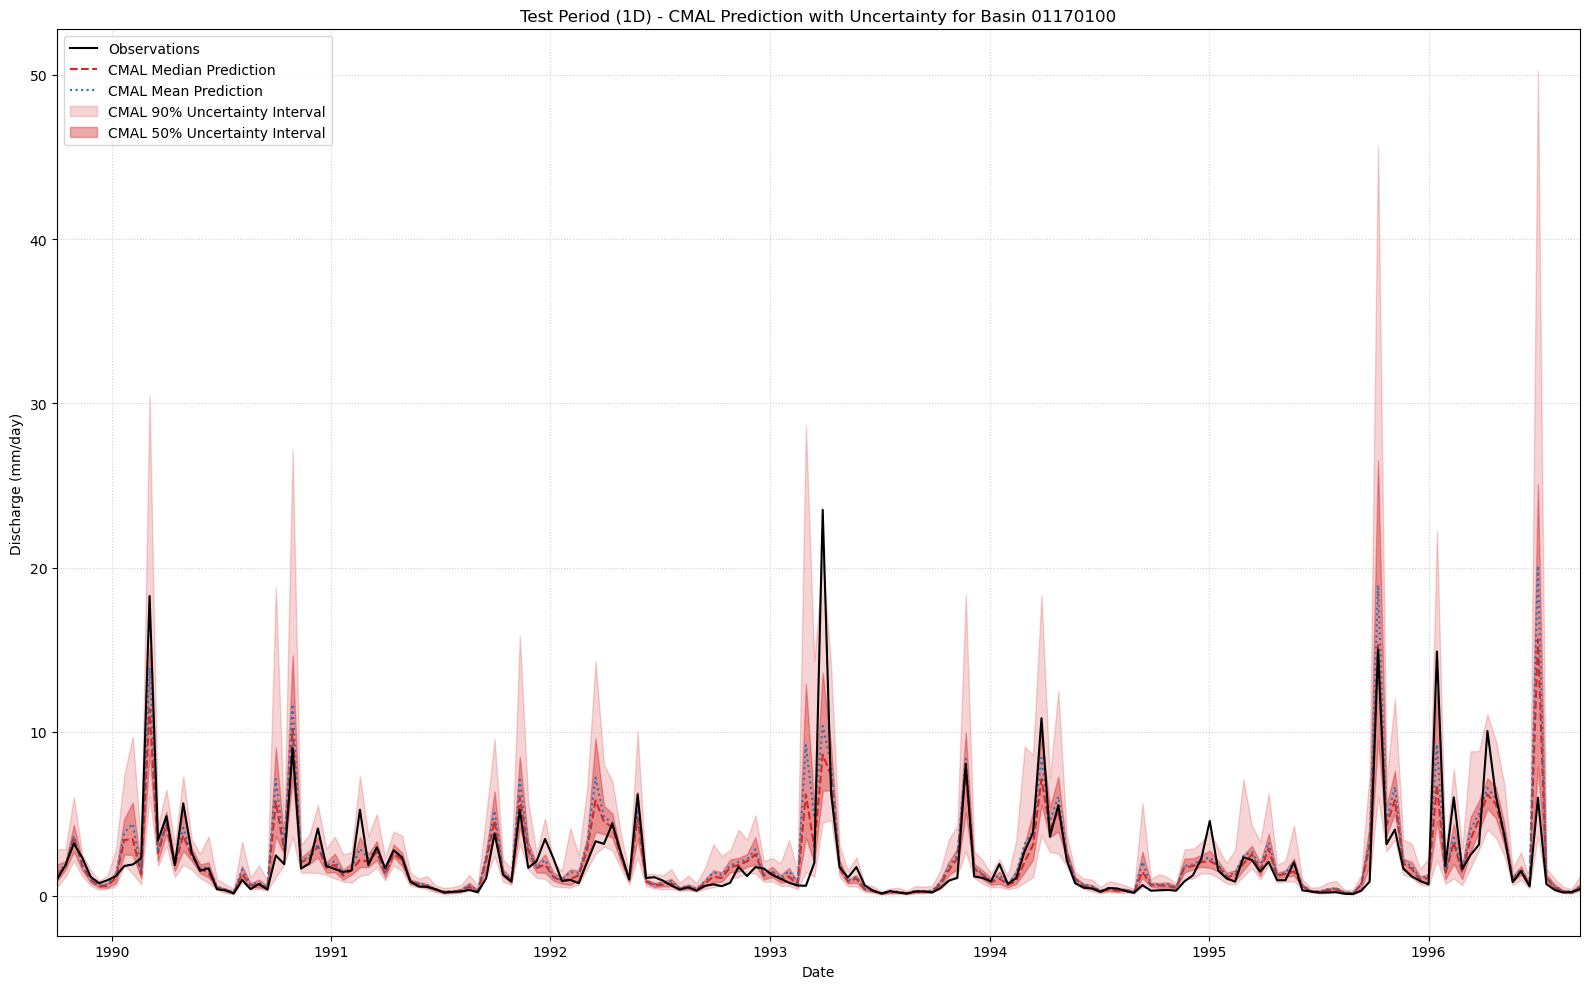

In [5]:
# --- 1. USER CONFIGURATION ---
# Simply change these two variables to plot different basins or frequencies
basin_id = '01170100'
freq = '1D'  # Try changing this to '1D', '2W-MON', '28D', etc.

# --- 2. DYNAMICALLY DETERMINE TARGET VARIABLE ---
# This block replaces the rigid if/elif structure.

# Define the base name of the variable. This makes it easy to change if you ever
# want to plot something other than discharge.
base_target_variable = 'QObs(mm/day)'

if freq == '1D':
    # For the daily frequency ('1D'), the variable name has no suffix.
    target_variable = base_target_variable
else:
    # For all other frequencies, we assume the target variable is constructed by
    # appending a suffix based on the frequency key.
    # We will derive the suffix from the part of the frequency string before a hyphen.
    # e.g., '2W-MON' -> '2W', '4W-MON' -> '4W', '14D' -> '14D'
    # IMPORTANT: This requires that your preprocessed column names match this pattern.
    # For example, if freq is '14D', your column must be named 'QObs(mm/day)_14D'.
    # If your column is named 'QObs(mm/day)_2W', you should hard-code the suffix here.
    suffix = freq.split('-')[0].upper()
    target_variable = f"{base_target_variable}_{suffix}"

print(f"Plotting frequency '{freq}' using target variable '{target_variable}'")


# --- 3. DATA EXTRACTION ---
try:
    results_xr = results[basin_id][freq]['xr']
    qobs = results_xr[f'{target_variable}_obs']
    qsim_with_samples = results_xr[f'{target_variable}_sim']
except KeyError:
    print(f"ERROR: Could not find results for basin '{basin_id}', frequency '{freq}', or variable '{target_variable}'.")
    print("Please check that:")
    print(f"  1. The frequency '{freq}' exists in your results.")
    print(f"  2. The target variable '{target_variable}' was used during training and exists in the output files.")
    raise

# --- 4. CALCULATE QUANTILES & MEAN ---
# This part of the code is already general and does not need changes.
median_sim = qsim_with_samples.quantile(0.5, dim='samples')
q25 = qsim_with_samples.quantile(0.25, dim='samples')
q75 = qsim_with_samples.quantile(0.75, dim='samples')
q05 = qsim_with_samples.quantile(0.05, dim='samples')
q95 = qsim_with_samples.quantile(0.95, dim='samples')
mean_sim = qsim_with_samples.mean(dim='samples')


# --- 5. Plotting with Matplotlib for Uncertainty ---
# This part of the code is also general and does not need changes.
fig, ax = plt.subplots(figsize=(16, 10))

# Using .squeeze() is good practice to remove any leftover dimensions of size 1
ax.plot(qobs['date'].values, qobs.values.squeeze(), color='black', label='Observations', linewidth=1.5, zorder=5)

ax.plot(median_sim['date'].values, median_sim.values.squeeze(), color='#d62728', linestyle='--', label='CMAL Median Prediction', linewidth=1.5)
ax.plot(mean_sim['date'].values, mean_sim.values.squeeze(), color='#1f77b4', linestyle=':', label='CMAL Mean Prediction', linewidth=1.5)

ax.fill_between(
    q05['date'].values,
    q05.values.squeeze(),
    q95.values.squeeze(),
    color='#d62728',
    alpha=0.2,
    label='CMAL 90% Uncertainty Interval'
)

ax.fill_between(
    q25['date'].values,
    q25.values.squeeze(),
    q75.values.squeeze(),
    color='#d62728',
    alpha=0.4,
    label='CMAL 50% Uncertainty Interval'
)

# --- Formatting ---
ax.set_ylabel("Discharge (mm/day)")
ax.set_xlabel("Date")
ax.set_title(f"Test Period ({freq}) - CMAL Prediction with Uncertainty for Basin {basin_id}")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim([qobs['date'].values.min(), qobs['date'].values.max()])
plt.tight_layout()
plt.show()

In [9]:
qobs_1d = qobs.squeeze()
mean_sim_1d = mean_sim.squeeze()

# Calculate all metrics for the median prediction
values = metrics.calculate_all_metrics(qobs_1d, mean_sim_1d)

# Print the calculated metrics
print("\nMetrics for CMAL Median Prediction:")
for key, val in values.items():
    print(f"{key}: {val:.3f}")


Metrics for CMAL Median Prediction:
NSE: 0.761
MSE: 1.319
RMSE: 1.149
KGE: 0.845
Alpha-NSE: 1.059
Beta-KGE: 1.093
Beta-NSE: 0.070
Pearson-r: 0.891
FHV: 6.038
FMS: -11.470
FLV: 10.565
Peak-Timing: nan
Peak-MAPE: 17.884


Generating uncertainty plots for basin 01170100 at 1D frequency...
Found matching target variable: 'QObs(mm/day)'

Using 'percentile_plot' (full hydrograph)...


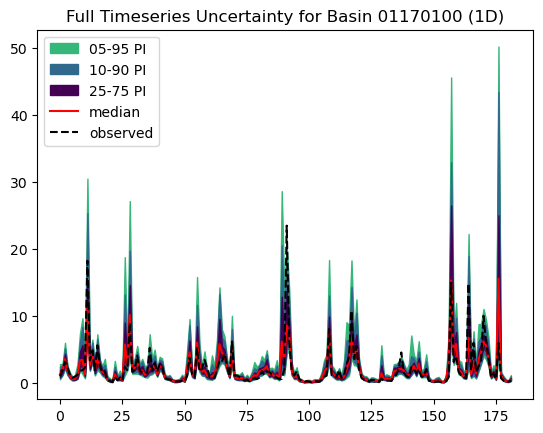

In [ ]:
from neuralhydrology.evaluation.plots import uncertainty_plot, percentile_plot
from neuralhydrology.utils.config import Config

try:
    cfg = Config(run_dir / "config.yml")
except (NameError, FileNotFoundError):
    raise RuntimeError("The 'run_dir' variable is not defined or 'config.yml' is missing.")

# --- 3. Configuration ---
# Simply change these two variables to plot different basins or frequencies
basin_id = '01170100'
freq = '1D'  # Try changing this to '14D', '2W-MON', etc.

# --- THIS IS THE NEW, MORE ROBUST LOGIC ---
# This method relies on the parallel ordering of the lists in your config file,
# which is the standard convention for multi-timescale models in neuralhydrology.

try:
    # Get the list of frequencies used in the run
    frequencies_list = cfg.use_frequencies
    # Get the corresponding list of target variables
    targets_list = cfg.target_variables

    # Sanity check: These lists must have the same length.
    if len(frequencies_list) != len(targets_list):
        raise ValueError("The 'use_frequencies' and 'target_variables' lists in your config.yml must have the same number of items.")

    # Find the index (position) of the frequency you want to plot
    freq_index = frequencies_list.index(freq)

    # Use that same index to get the correct target variable
    target_variable = targets_list[freq_index]

except ValueError as e:
    # This will catch errors if the freq isn't in the list or if the lists have different lengths.
    print(f"ERROR: Could not find a match for frequency '{freq}'.")
    print(f"Available frequencies in config: {frequencies_list}")
    raise e
# --- END OF NEW LOGIC ---

# Define the variable names to extract from the results xarray
obs_var_name = f"{target_variable}_obs"
samples_var_name = f"{target_variable}_sim"

print(f"Generating uncertainty plots for basin {basin_id} at {freq} frequency...")
print(f"Found matching target variable: '{target_variable}'")

# --- 4. Data Extraction and Reshaping ---
try:
    xr_data = results[basin_id][freq]['xr']
    
    if samples_var_name not in xr_data:
        raise KeyError(f"The samples variable '{samples_var_name}' was not found in the results file!")

    obs_data_np = xr_data[obs_var_name].values
    samples_data_np = xr_data[samples_var_name].values
    
    # Reshape observations: Add a 'feature' dimension if it's missing
    # This makes the data compatible with the plotting functions.
    if obs_data_np.ndim == 1:
        y_obs_reshaped = np.expand_dims(obs_data_np, axis=1)
    else:
        y_obs_reshaped = obs_data_np

    # Reshape samples: Add a 'feature' dimension if it's missing
    if samples_data_np.ndim == 2:
        y_samples_reshaped = np.expand_dims(samples_data_np, axis=1)
    else:
        y_samples_reshaped = samples_data_np
        
except KeyError as e:
    print(f"CRITICAL ERROR: {e}")
    print("\nSomething went wrong during data extraction.")
    print("Please double-check your `basin_id` and `freq` variables.")
    if 'xr_data' in locals():
        print(f"Available variables in the results file for this frequency are: {list(xr_data.keys())}")
    raise

# --- 5. Call the Official Plotting Functions ---
# You can uncomment this section to generate the first plot type
# print("\nUsing 'uncertainty_plot' (reliability + hydrograph zoom-in)...")
# fig, axes = uncertainty_plot(y=y_obs_reshaped,
#                            y_hat=y_samples_reshaped,
#                            title=f"Uncertainty for Basin {basin_id} ({freq})")
# plt.show()

print("\nUsing 'percentile_plot' (full hydrograph)...")
fig2, ax2 = percentile_plot(y=y_obs_reshaped,
                            y_hat=y_samples_reshaped,
                            title=f"Full Timeseries Uncertainty for Basin {basin_id} ({freq})")
plt.show()

      Running Probabilistic Analysis for Timescale: 14D      
Performing probabilistic evaluation on 182 timesteps with 100 samples each.

Calculating reliability...
Calculating resolution (sharpness)...


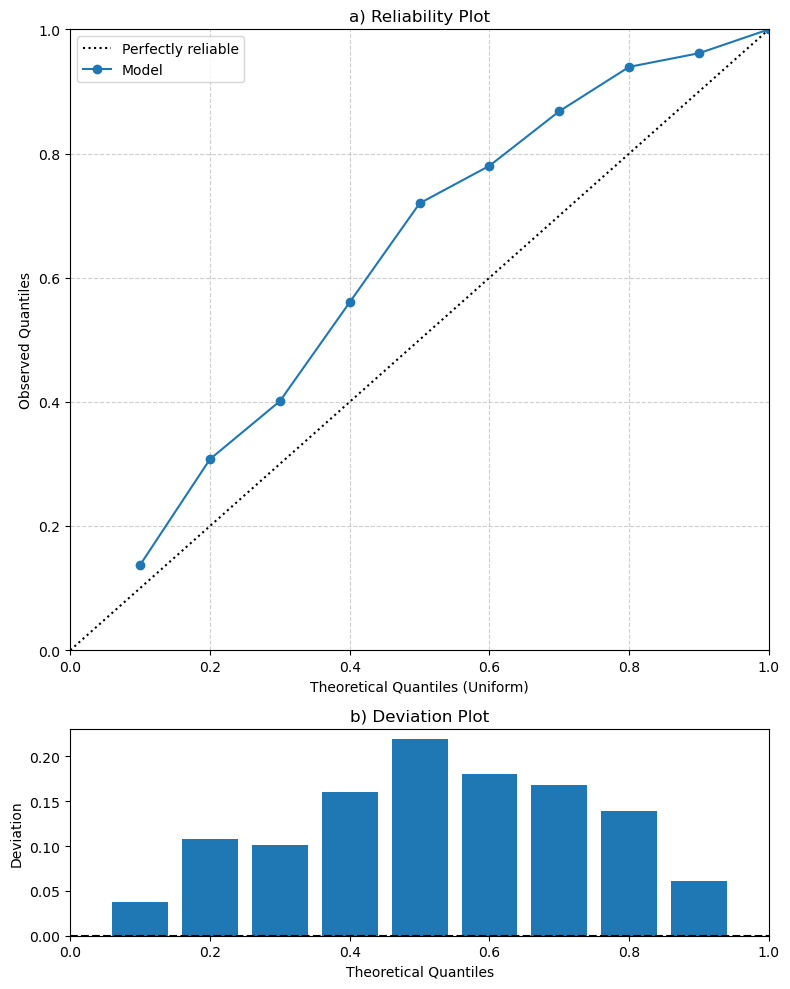


Resolution Metrics (lower is better):
  - mean_std_dev: 0.7816
  - mean_interquartile_range: 0.8792
  - mean_interdecile_range: 1.7648
      Running Probabilistic Analysis for Timescale: 1D      
Performing probabilistic evaluation on 182 timesteps with 100 samples each.

Calculating reliability...
Calculating resolution (sharpness)...


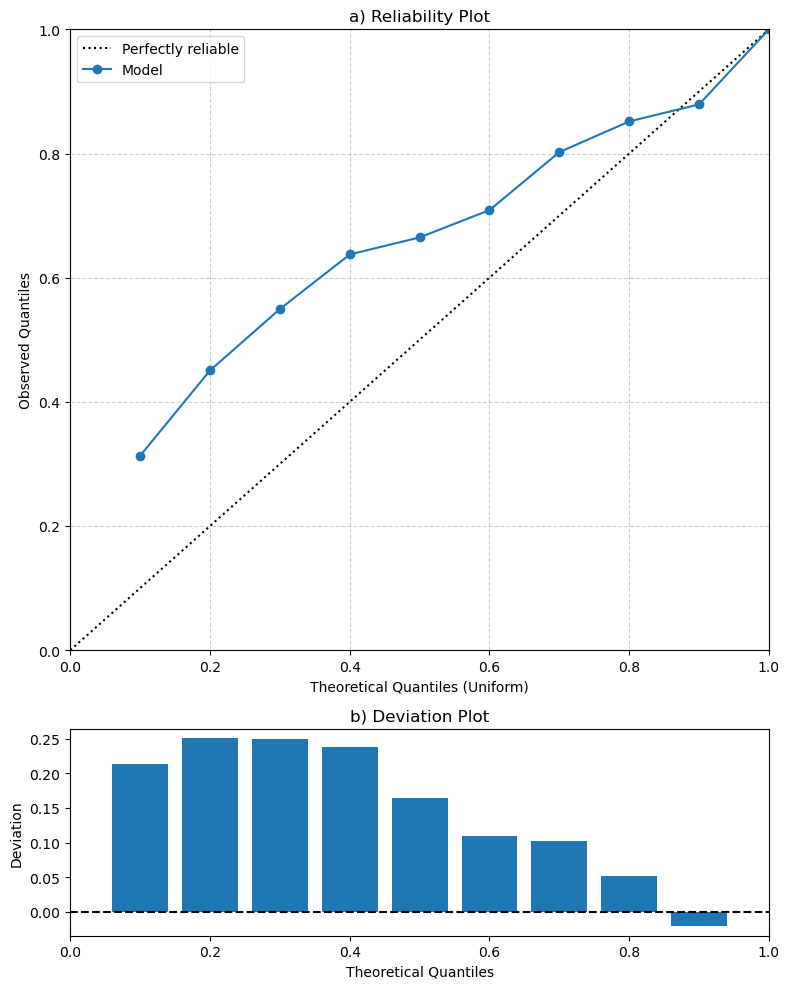


Resolution Metrics (lower is better):
  - mean_std_dev: 0.7461
  - mean_interquartile_range: 0.8085
  - mean_interdecile_range: 1.6645


In [18]:
# Make sure 'run_dir' is pointing to your correctly evaluated run folder
try:
    cfg = Config(run_dir / "config.yml")
except NameError:
    raise NameError("The 'run_dir' variable is not defined. Please define it before this cell.")

# --- 3. Configuration ---
basin_id = '01170100'       # The basin ID you are analyzing
target_variable = cfg.target_variables[0] # Dynamically get target from config

# Define the variable names to look for in the results file
obs_var_name = f"{target_variable}_obs"

# ######################################################################
# ################         THIS IS THE CRITICAL FIX         ##############
# The UncertaintyTester saves samples under the '_sim' key.
samples_var_name = f"{target_variable}_sim"
# ######################################################################
# ######################################################################


# --- 4. Loop through frequencies and run analysis ---
if basin_id not in results:
    raise ValueError(f"Basin {basin_id} not found in results. Available basins: {list(results.keys())}")

for frequency in cfg.use_frequencies: 
    print("======================================================================")
    print(f"      Running Probabilistic Analysis for Timescale: {frequency}      ")
    print("======================================================================")

    try:
        # Extract the xarray Dataset for the current frequency
        xr_data = results[basin_id][frequency]['xr']
        
        # Extract observations and simulation samples using the correct variable names
        obs_data_multidim = xr_data[obs_var_name].values
        sim_samples_multidim = xr_data[samples_var_name].values

        # --- Data Reshaping to get 1D (obs) and 2D (samples) arrays ---
        # Flatten all time dimensions into a single long timeseries
        obs_data_flat = obs_data_multidim.flatten()
        
        # Reshape samples to (total_timesteps, n_samples)
        num_samples = sim_samples_multidim.shape[-1]
        sim_samples_reshaped = sim_samples_multidim.reshape(-1, num_samples)
            
        # --- Handle NaNs ---
        valid_indices = ~np.isnan(obs_data_flat)
        if not np.all(valid_indices):
            print(f"Warning: Found and removed {np.sum(~valid_indices)} NaN values in observations.")
            obs_data = obs_data_flat[valid_indices]
            sim_samples = sim_samples_reshaped[valid_indices, :]
        else:
            obs_data = obs_data_flat
            sim_samples = sim_samples_reshaped

        # --- Run the analysis ---
        probabilistic_results = run_probabilistic_evaluation(obs=obs_data, sim_samples=sim_samples)

    except KeyError as e:
        print(f"\nCould not run analysis for frequency '{frequency}'.")
        # Update the error message to be more informative
        print(f"A required data variable was not found. Tried to find '{obs_var_name}' and '{samples_var_name}'.")
        print(f"Available variables are: {list(xr_data.keys())}\n")
    except Exception as e:
        print(f"\nAn unexpected error occurred for frequency '{frequency}': {e}\n")

In [ ]:
# Select a random basins from the lower 50% of the NSE distribution
basin = df.loc[df["QObs(mm/day)_NSE_1D"] < df["QObs(mm/day)_NSE_1D"].median()].sample(n=1).index[0]

print(f"Selected basin: {basin} with an NSE of {df.loc[df.index == basin, 'QObs(mm/day)_NSE_1D'].values[0]:.3f}")

Selected basin: 01170100 with an NSE of 0.502


In [ ]:
# Add the path to the pre-trained model to the finetune config
with open("finetune.yml", "a") as fp:
    fp.write(f"\nbase_run_dir: {run_dir.absolute()}")
    
# Create a basin file with the basin we selected above
with open("finetune_basin.txt", "w") as fp:
    fp.write(basin)

In [ ]:
finetune(Path("finetune.yml"))

DuplicateKeyError: while constructing a mapping
  in "finetune.yml", line 4, column 1
found duplicate key "base_run_dir" with value "d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1311_060515" (original value: "d:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1311_060515")
  in "finetune.yml", line 24, column 1

To suppress this check see:
    http://yaml.readthedocs.io/en/latest/api.html#duplicate-keys


In [ ]:
finetune_dir = Path("runs/mtslstmcmal_basins_finetuned_1411_013934")
eval_run(finetune_dir, period="test")

In [ ]:
# load test results of the base run
df_pretrained = pd.read_csv(run_dir / "test/model_epoch020/test_metrics.csv", dtype={'basin': str})
df_pretrained = df_pretrained.set_index("basin")
    
# load test results of the finetuned model
df_finetuned = pd.read_csv(finetune_dir / "test/model_epoch050/test_metrics.csv", dtype={'basin': str})
df_finetuned = df_finetuned.set_index("basin")
    
# extract basin performance
base_model_nse = df_pretrained.loc[df_pretrained.index == basin, "QObs(mm/day)_2W_NSE_2W-MON"].values[0]
finetune_nse = df_finetuned.loc[df_finetuned.index == basin, "QObs(mm/day)_2W_NSE_2W-MON"].values[0]
print(f"Basin {basin} base model performance: {base_model_nse:.3f}")
print(f"Performance after finetuning: {finetune_nse:.3f}")

NameError: name 'finetune_dir' is not defined

In [2]:
run_dir = Path("runs/test_run_1811_030157")
from neuralhydrology.evaluation.evaluate import start_evaluation 

cfg = Config(run_dir / "config.yml")

cfg.update_config({
    "test_start_date": "16/09/2012",
    "test_end_date": "16/02/2013",
    "test_basin_file": Path(r"D:\github\neuralhydrology\neuralhydrology\data\forecast\my_basins.txt")
})

# Step 2: Manually attach your custom flag to the config object.
# This happens *after* the validation and completely bypasses the error.
cfg.run_mode = "operational"

# --- END OF CORRECTION ---


print("--- STARTING OPERATIONAL FORECAST ---")
# When start_evaluation is called, the cfg object now carries the extra 'run_mode' attribute,
# which your custom data loader will be able to find and use.
start_evaluation(cfg=cfg, run_dir=run_dir)
print("--- OPERATIONAL FORECAST COMPLETE ---")

--- STARTING OPERATIONAL FORECAST ---


d:\github\neuralhydrology\neuralhydrology\neuralhydrology\evaluation\tester.py:143: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(weigh

# Evaluation:   0%|          | 0/671 [00:00<?, ?it/s]
[CONFIRMATION] EXPLICIT OPERATIONAL MODE. Loading forecast data from: D:\github\neuralhydrology\neuralhydrology\data\forecast\forecasts_processed\01013500_operational_forecast.csv

DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 1/671 [00:01<17:06,  1.53s/it]
[CONFIRMATION] EXPLICIT OPERATIONAL MODE. Loading forecast data from: D:\github\neuralhydrology\neuralhydrology\data\forecast\forecasts_processed\01022500_operational_forecast.csv

DEBUG: Creating data variables using UNCERTAINTY logic.
DEBUG: Creating data variables using UNCERTAINTY logic.
# Evaluation:   0%|          | 2/671 [00:01<07:59,  1.39it/s]
[CONFIRMATION] EXPLICIT OPERATIONAL MODE. Loading forecast data from: D:\github\neuralhydrology\neuralhydrology\data\forecast\forecasts_processed\01030500_operational_forecast.csv

DEBUG: Creating data variables using UNCERTAINTY logic.

Loading model predictions from: D:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1811_030157\test\model_epoch020\test_results.p
Predictions loaded successfully.
Plotting frequency '14D' using target variable 'QObs(mm/day)_2W'
Loading historical observations for comparison...
Successfully loaded and sliced observations from 2012-09-16T00:00:00.000000000 to 2013-02-03T00:00:00.000000000.


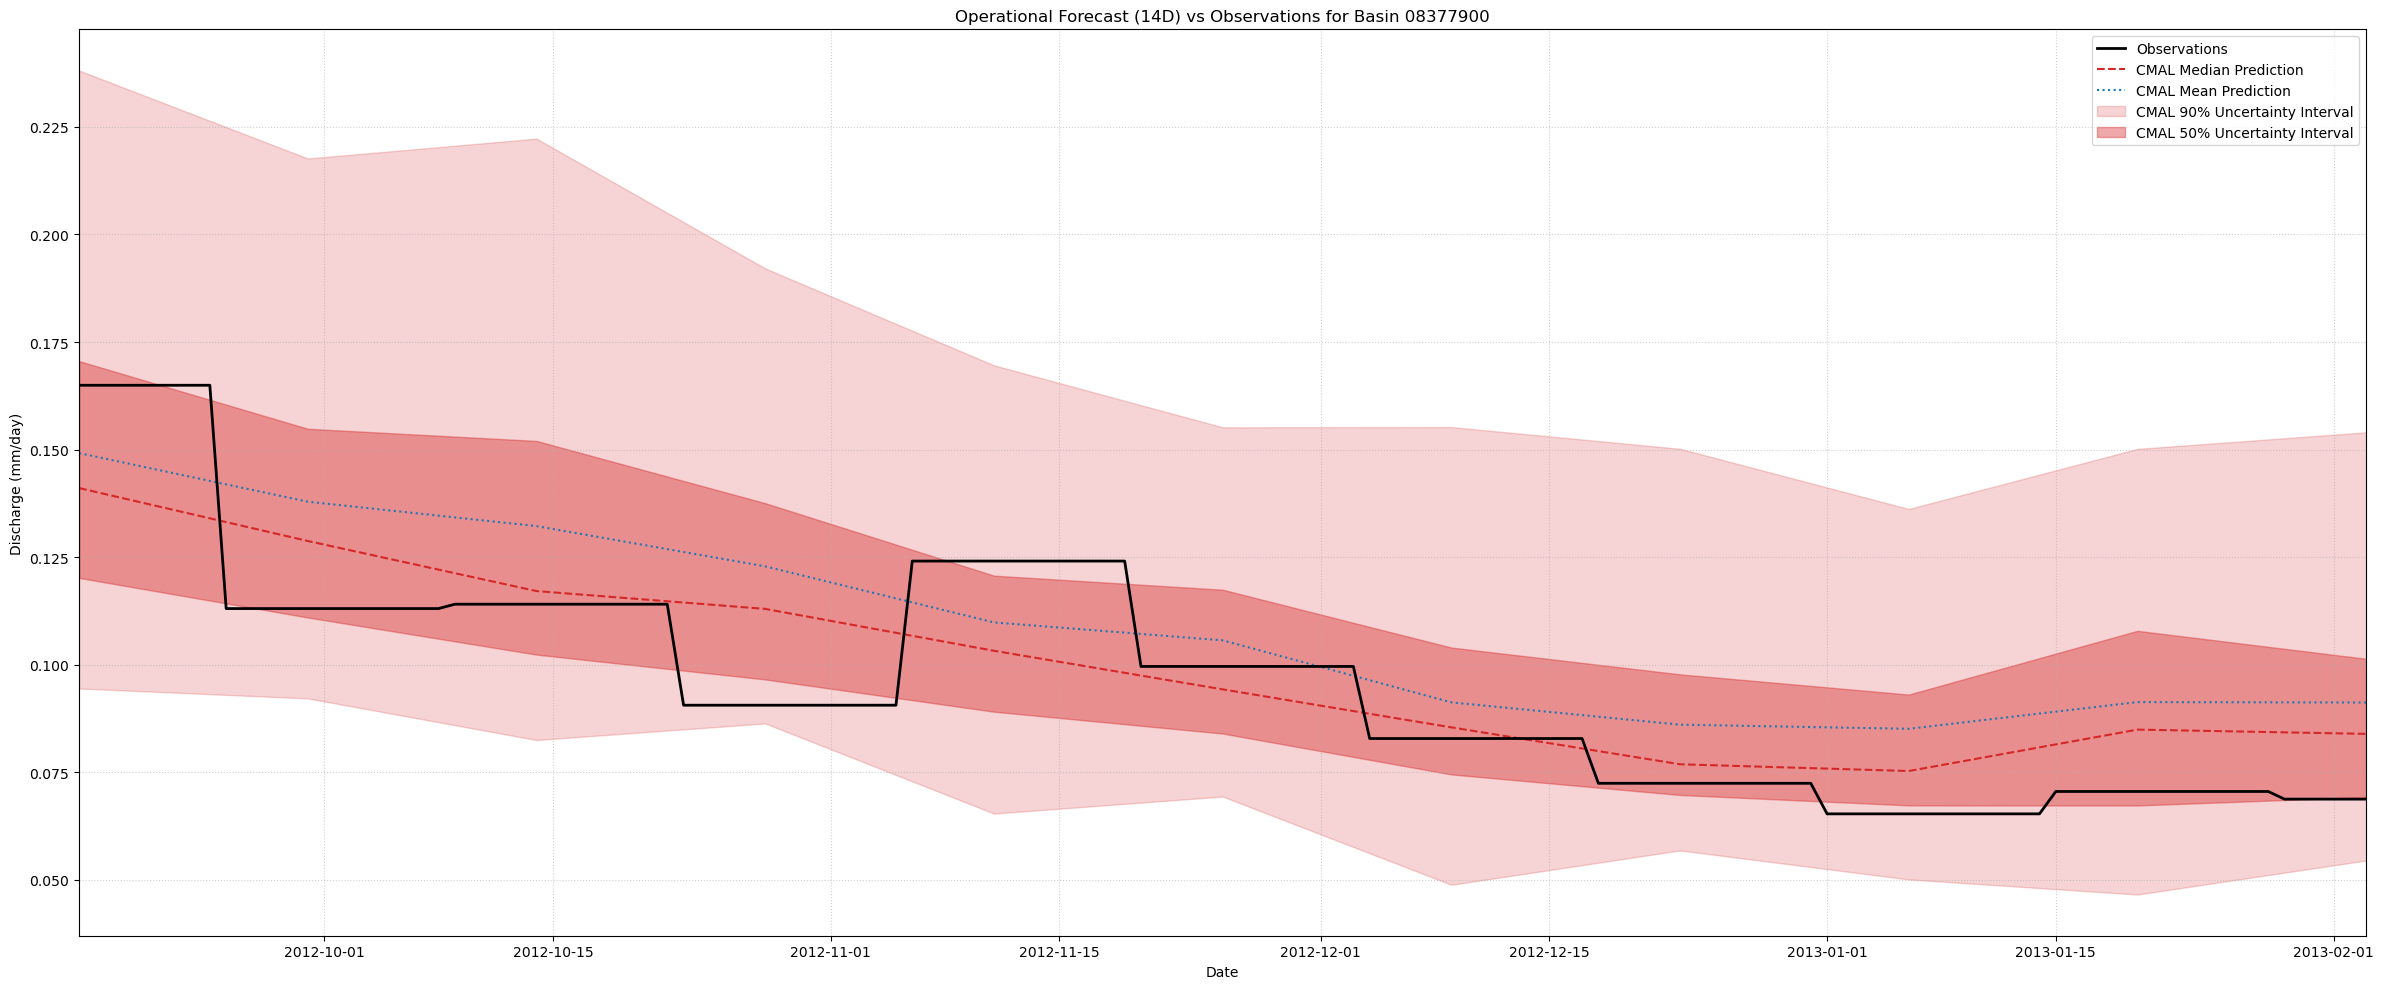

In [9]:
# --- 1. Load the Model's PREDICTIONS ---
run_dir = Path(r"D:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1811_030157")
results_file = run_dir / "test" / "model_epoch020" / "test_results.p"

print(f"Loading model predictions from: {results_file}")
with open(results_file, 'rb') as fp:
    results = pickle.load(fp)
print("Predictions loaded successfully.")

# Load the config to get model settings
cfg = Config(run_dir / "config.yml")

# --- 2. Configuration for the Plot ---
basin_id = '08377900' 
freq = '14D'

# --- 3. Dynamically determine the target variable name ---
# This part is correct and remains the same.
base_target_variable = 'QObs(mm/day)'
if freq == '1D':
    target_variable = base_target_variable
else:
    target_variable_map = {
        '14D': 'QObs(mm/day)_2W',
        '28D': 'QObs(mm/day)_4W'
    } 
    target_variable = target_variable_map.get(freq, f"{base_target_variable}_{freq}")

print(f"Plotting frequency '{freq}' using target variable '{target_variable}'")

# --- 4. Extract Model Simulations ---
# We only extract the simulations (_sim) from the results file.
try:
    results_xr = results[basin_id][freq]['xr']
    qsim_with_samples = results_xr[f'{target_variable}_sim']
except KeyError:
    print(f"ERROR: Could not find simulation data for basin '{basin_id}' or frequency '{freq}'.")
    raise

# --- 5. (NEW) Load Historical OBSERVATIONS from separate file ---
print("Loading historical observations for comparison...")
try:
    # Define the path to your preprocessed streamflow data
    obs_dir = Path(r"D:\github\neuralhydrology\neuralhydrology\data\CAMELS_US\usgs_streamflow_preprocessed")
    
    # Find the specific observation file for the basin
    obs_files = list(obs_dir.glob(f"**/{basin_id}_*.csv"))
    if not obs_files:
        raise FileNotFoundError(f"No observation file found for basin {basin_id} in {obs_dir}")
    
    # Load the entire historical observation file
    obs_df_full = pd.read_csv(obs_files[0], index_col='date', parse_dates=True)
    
    # Get the date range from our model's predictions
    start_date = qsim_with_samples['date'].min().values
    end_date = qsim_with_samples['date'].max().values
    
    # Slice the historical observations to match the exact forecast period
    qobs_sliced = obs_df_full[target_variable].loc[start_date:end_date]
    print(f"Successfully loaded and sliced observations from {start_date} to {end_date}.")

except Exception as e:
    print(f"Warning: Could not load historical observations. Plot will not include them. Reason: {e}")
    qobs_sliced = None # Set to None if loading fails

# --- 6. Calculate Quantiles & Mean from Simulations ---
# This part is correct and remains the same.
median_sim = qsim_with_samples.quantile(0.5, dim='samples')
q25 = qsim_with_samples.quantile(0.25, dim='samples')
q75 = qsim_with_samples.quantile(0.75, dim='samples')
q05 = qsim_with_samples.quantile(0.05, dim='samples')
q95 = qsim_with_samples.quantile(0.95, dim='samples')
mean_sim = qsim_with_samples.mean(dim='samples')

# --- 7. Plotting (Now with external observations) ---
fig, ax = plt.subplots(figsize=(24, 10)) # Made the plot wider

# (MODIFIED) Plot observations ONLY if they were loaded successfully
if qobs_sliced is not None:
    ax.plot(qobs_sliced.index, qobs_sliced.values, color='black', label='Observations', linewidth=2, zorder=10)

# The rest of the plotting is the same
ax.plot(median_sim['date'].values, median_sim.values.squeeze(), color='#d62728', linestyle='--', label='CMAL Median Prediction', linewidth=1.5)
ax.plot(mean_sim['date'].values, mean_sim.values.squeeze(), color='#1f77b4', linestyle=':', label='CMAL Mean Prediction', linewidth=1.5)
ax.fill_between(q05['date'].values, q05.values.squeeze(), q95.values.squeeze(), color='#d62728', alpha=0.2, label='CMAL 90% Uncertainty Interval')
ax.fill_between(q25['date'].values, q25.values.squeeze(), q75.values.squeeze(), color='#d62728', alpha=0.4, label='CMAL 50% Uncertainty Interval')

ax.set_ylabel("Discharge (mm/day)")
ax.set_xlabel("Date")
ax.set_title(f"Operational Forecast ({freq}) vs Observations for Basin {basin_id}")
ax.legend()
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim([qsim_with_samples['date'].min().values, qsim_with_samples['date'].max().values])
plt.tight_layout()
plt.show()

Model predictions loaded successfully.

      Running Reliability Analysis for Timescale: 14D      
Loading historical observations from 2012-09-16 to 2013-02-03...
Generating custom reliability and deviation plots...


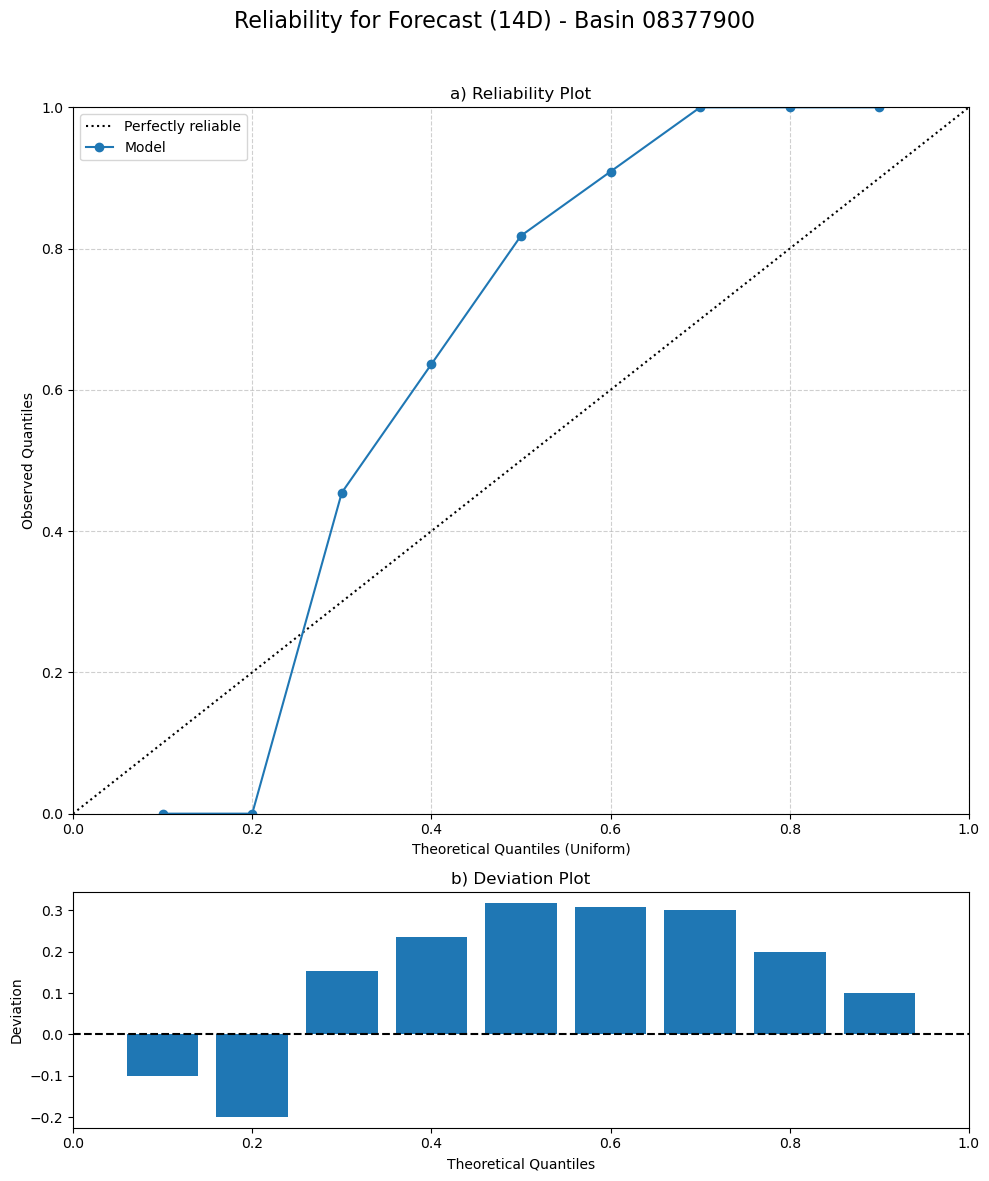


      Running Reliability Analysis for Timescale: 1D      
Loading historical observations from 2012-09-16 to 2013-02-03...
Generating custom reliability and deviation plots...


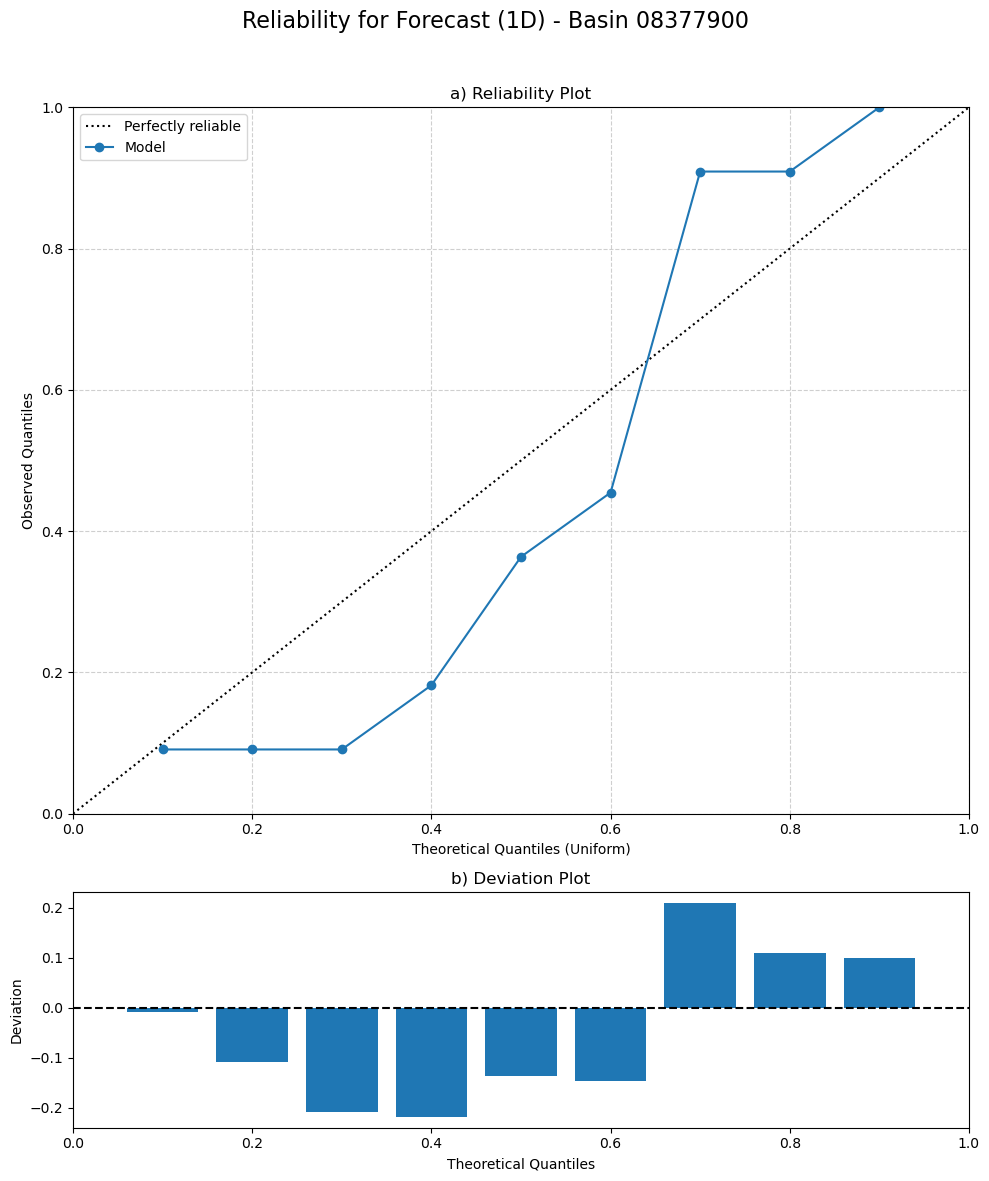

In [7]:
# |          CUSTOM FUNCTION TO CREATE THE RELIABILITY PLOT          |
# |                  (This function is correct)                      |
# +------------------------------------------------------------------+
def create_reliability_plot(obs: np.ndarray, sim_samples: np.ndarray, title: str):
    """Manually creates the two-panel reliability and deviation plot."""
    print("Generating custom reliability and deviation plots...")
    
    theoretical_quantiles = np.arange(0.1, 1.0, 0.1)
    observed_quantiles = []

    for q in theoretical_quantiles:
        predicted_q_values = np.percentile(sim_samples, q * 100, axis=1)
        is_obs_less_than_pred = obs < predicted_q_values
        observed_fraction = np.mean(is_obs_less_than_pred)
        observed_quantiles.append(observed_fraction)
        
    observed_quantiles = np.array(observed_quantiles)
    deviations = observed_quantiles - theoretical_quantiles

    fig, axes = plt.subplots(2, 1, figsize=(10, 12), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle(title, fontsize=16)
    
    ax1 = axes[0]; ax1.plot([0, 1], [0, 1], 'k:', label='Perfectly reliable'); ax1.plot(theoretical_quantiles, observed_quantiles, 'o-', label='Model')
    ax1.set_xlim([0, 1]); ax1.set_ylim([0, 1]); ax1.set_title('a) Reliability Plot'); ax1.set_xlabel('Theoretical Quantiles (Uniform)'); ax1.set_ylabel('Observed Quantiles')
    ax1.grid(True, linestyle='--', alpha=0.6); ax1.legend()
    ax2 = axes[1]; ax2.bar(theoretical_quantiles, deviations, width=0.08); ax2.axhline(0, color='black', linestyle='--')
    ax2.set_xlim([0, 1]); ax2.set_title('b) Deviation Plot'); ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Deviation')
    plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

# +------------------------------------------------------------------+
# |                MAIN SCRIPT TO RUN THE ANALYSIS                 |
# +------------------------------------------------------------------+

run_dir = Path(r"D:\github\neuralhydrology\neuralhydrology\own\operational_forecast\runs\test_run_1811_030157")
cfg = Config(run_dir / "config.yml")
results_file = run_dir / "test" / "model_epoch020" / "test_results.p"
with open(results_file, 'rb') as fp:
    results = pickle.load(fp)
print("Model predictions loaded successfully.")

basin_id = '08377900' 

if basin_id not in results:
    raise ValueError(f"Basin {basin_id} not found in results.")

for frequency in cfg.use_frequencies: 
    print("\n" + "="*70)
    print(f"      Running Reliability Analysis for Timescale: {frequency}      ")
    print("="*70)

    try:
        freq_index = cfg.use_frequencies.index(frequency)
        target_variable = cfg.target_variables[freq_index]
        samples_var_name = f"{target_variable}_sim"
        
        # --- Extract SIMULATIONS as an xarray DataArray ---
        simulations_xr = results[basin_id][frequency]['xr'][samples_var_name]
        
        start_date = pd.to_datetime(simulations_xr['date'].min().values)
        end_date = pd.to_datetime(simulations_xr['date'].max().values)

        # --- Load and Slice OBSERVATIONS ---
        print(f"Loading historical observations from {start_date.date()} to {end_date.date()}...")
        obs_dir = Path(r"D:\github\neuralhydrology\neuralhydrology\data\CAMELS_US\usgs_streamflow_preprocessed")
        obs_files = list(obs_dir.glob(f"**/{basin_id}_*.csv"))
        obs_df_full = pd.read_csv(obs_files[0], index_col='date', parse_dates=True)
        obs_data_sliced_daily = obs_df_full[target_variable].loc[start_date:end_date]

        # ######################################################################
        # ################         THIS IS THE CRITICAL FIX         ##############
        # ######################################################################
        
        # Resample the daily-indexed observations to match the simulation frequency
        obs_data_resampled = obs_data_sliced_daily.resample(frequency).mean()

        # Align both datasets using their shared datetime index. This is the key step.
        # It ensures they have the exact same length and timestamps.
        aligned_sims, aligned_obs = xr.align(simulations_xr, obs_data_resampled.to_xarray(), join='inner')
        
        # --- Convert to numpy arrays AFTER alignment ---
        obs_data_aligned = aligned_obs.to_numpy()
        # Reshape simulations to be 2D: (time, samples)
        sim_samples_aligned = aligned_sims.to_numpy().reshape(-1, aligned_sims.shape[-1])
        
        # ######################################################################
        
        # --- Handle NaNs on the now-aligned data ---
        valid_indices = ~np.isnan(obs_data_aligned)
        
        obs_data_final = obs_data_aligned[valid_indices]
        sim_samples_final = sim_samples_aligned[valid_indices, :]

        if len(obs_data_final) == 0:
            print("No valid overlapping observations found. Skipping analysis.")
            continue
            
        if len(obs_data_final) < 20 and frequency != '1D':
             print(f"Warning: Only {len(obs_data_final)} valid data points for frequency '{frequency}'. Reliability plot may be misleading.")

        plot_title = f"Reliability for Forecast ({frequency}) - Basin {basin_id}"
        create_reliability_plot(obs=obs_data_final, sim_samples=sim_samples_final, title=plot_title)

    except KeyError as e:
        print(f"\nCould not run analysis for frequency '{frequency}'. Error: {e}")
    except Exception as e:
        print(f"\nAn unexpected error occurred for frequency '{frequency}': {e}")

In [5]:
# --- Helper functions for metric calculation ---

def calculate_crps(obs: np.ndarray, sim_samples: np.ndarray) -> float:
    """Calculate the Continuous Ranked Probability Score (CRPS). Lower is better."""
    m = sim_samples.shape[1]
    term1 = np.sum(np.abs(sim_samples - obs[:, None]), axis=-1) / m
    term2 = np.sum(np.abs(sim_samples[:, None, :] - sim_samples[:, :, None]), axis=(-1, -2)) / (2 * m**2)
    return np.mean(term1 - term2)

def calculate_nse(obs: np.ndarray, sim: np.ndarray) -> float:
    """Calculate the Nash-Sutcliffe Efficiency (NSE). Higher is better."""
    return 1 - (np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2))

def calculate_kge(obs: np.ndarray, sim: np.ndarray) -> float:
    """Calculate the Kling-Gupta Efficiency (KGE). Higher is better."""
    r = np.corrcoef(obs, sim)[0, 1]
    alpha = np.std(sim) / np.std(obs)
    beta = np.mean(sim) / np.mean(obs)
    return 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# The frequency you want to evaluate
frequency_to_evaluate = '14D'

# 3. ## LOOP THROUGH BASINS AND CALCULATE METRICS ##
all_basin_results = []
basin_list = list(results.keys())

for i, basin_id in enumerate(basin_list):
    print(f"Processing basin {i+1}/{len(basin_list)}: {basin_id}")
    
    try:
        # --- Get variable names ---
        freq_index = cfg.use_frequencies.index(frequency_to_evaluate)
        target_variable = cfg.target_variables[freq_index]
        samples_var_name = f"{target_variable}_sim"
        
        # --- Extract simulations ---
        simulations_xr = results[basin_id][frequency_to_evaluate]['xr'][samples_var_name]
        start_date = pd.to_datetime(simulations_xr['date'].min().values)
        end_date = pd.to_datetime(simulations_xr['date'].max().values)

        # --- Load and slice observations ---
        obs_dir = Path(r"D:\github\neuralhydrology\neuralhydrology\data\CAMELS_US\usgs_streamflow_preprocessed")
        obs_files = list(obs_dir.glob(f"**/{basin_id}_*.csv"))
        obs_df_full = pd.read_csv(obs_files[0], index_col='date', parse_dates=True)
        obs_data_sliced_daily = obs_df_full[target_variable].loc[start_date:end_date]
        
        # --- Align obs and sims ---
        obs_data_resampled = obs_data_sliced_daily.resample(frequency_to_evaluate).mean()
        aligned_sims, aligned_obs = xr.align(simulations_xr, obs_data_resampled.to_xarray(), join='inner')
        
        obs_data_aligned = aligned_obs.to_numpy()
        sim_samples_aligned = aligned_sims.to_numpy().reshape(-1, aligned_sims.shape[-1])
        
        # --- Handle NaNs ---
        valid_indices = ~np.isnan(obs_data_aligned)
        obs_final = obs_data_aligned[valid_indices]
        sim_samples_final = sim_samples_aligned[valid_indices, :]
        
        if len(obs_final) == 0:
            print(f"  - Warning: No valid overlapping data for basin {basin_id}. Skipping.")
            continue
            
        # --- Calculate metrics ---
        # For NSE/KGE, we evaluate the median prediction, which is a common choice
        median_sim = np.median(sim_samples_final, axis=1)
        
        crps = calculate_crps(obs_final, sim_samples_final)
        nse = calculate_nse(obs_final, median_sim)
        kge = calculate_kge(obs_final, median_sim)
        
        # Store results for this basin
        all_basin_results.append({
            'basin_id': basin_id,
            'CRPS': crps,
            'NSE': nse,
            'KGE': kge,
            'n_timesteps': len(obs_final)
        })

    except Exception as e:
        print(f"  - ERROR processing basin {basin_id}: {e}")

# 4. ## ANALYZE AND RANK RESULTS ##
if not all_basin_results:
    print("\nNo basins were successfully evaluated. Cannot generate ranking.")
else:
    # Create a DataFrame from the results
    df = pd.DataFrame(all_basin_results)
    df = df.set_index('basin_id')
    
    # --- Rank by CRPS (lower is better) ---
    df_sorted_crps = df.sort_values(by='CRPS', ascending=True)
    
    print("\n" + "="*50)
    print(f"   Basin Performance Ranking (Frequency: {frequency_to_evaluate})")
    print("="*50)
    
    print("\n--- TOP 5 BEST Performing Basins (by CRPS, lower is better) ---")
    print(df_sorted_crps.head(5).round(3))
    
    print("\n--- TOP 5 WORST Performing Basins (by CRPS, lower is better) ---")
    print(df_sorted_crps.tail(5).round(3))

    # --- Optional: Rank by KGE (higher is better) ---
    df_sorted_kge = df.sort_values(by='KGE', ascending=False)
    
    print("\n\n--- TOP 5 BEST Performing Basins (by KGE, higher is better) ---")
    print(df_sorted_kge.head(5).round(3))
    
    print("\n--- TOP 5 WORST Performing Basins (by KGE, higher is better) ---")
    print(df_sorted_kge.tail(5).round(3))

    print("\n" + "="*50)
    print("           Overall Performance Summary")
    print("="*50)
    print(df.describe().round(3))

Processing basin 1/671: 01013500
Processing basin 2/671: 01022500
Processing basin 3/671: 01030500
Processing basin 4/671: 01031500
Processing basin 5/671: 01047000
Processing basin 6/671: 01052500
Processing basin 7/671: 01054200
Processing basin 8/671: 01055000
Processing basin 9/671: 01057000
Processing basin 10/671: 01073000
Processing basin 11/671: 01078000
Processing basin 12/671: 01118300
Processing basin 13/671: 01121000
Processing basin 14/671: 01123000
Processing basin 15/671: 01134500
Processing basin 16/671: 01137500
Processing basin 17/671: 01139000
Processing basin 18/671: 01139800
Processing basin 19/671: 01142500
Processing basin 20/671: 01144000
Processing basin 21/671: 01162500
Processing basin 22/671: 01169000
Processing basin 23/671: 01170100
Processing basin 24/671: 01181000
Processing basin 25/671: 01187300
Processing basin 26/671: 01195100
Processing basin 27/671: 01333000
Processing basin 28/671: 01350000
Processing basin 29/671: 01350080
Processing basin 30/671

c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processing basin 359/671: 06450500
Processing basin 360/671: 06452000
Processing basin 361/671: 06453600
Processing basin 362/671: 06464500
Processing basin 363/671: 06468170
Processing basin 364/671: 06468250
Processing basin 365/671: 06470800
Processing basin 366/671: 06477500
Processing basin 367/671: 06479215
Processing basin 368/671: 06479438
Processing basin 369/671: 06601000
Processing basin 370/671: 06614800
Processing basin 371/671: 06622700
Processing basin 372/671: 06623800
Processing basin 373/671: 06632400
Processing basin 374/671: 06746095
Processing basin 375/671: 06784000
Processing basin 376/671: 06803510
Processing basin 377/671: 06803530


c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Processing basin 378/671: 06814000
Processing basin 379/671: 06847900
Processing basin 380/671: 06853800
Processing basin 381/671: 06876700
Processing basin 382/671: 06878000
Processing basin 383/671: 06879650
Processing basin 384/671: 06885500
Processing basin 385/671: 06888500
Processing basin 386/671: 06889200


...

Processing basin 480/671: 08267500
Processing basin 481/671: 08269000
Processing basin 482/671: 08271000
Processing basin 483/671: 08324000
Processing basin 484/671: 08377900
Processing basin 485/671: 08378500
Processing basin 486/671: 08380500
Processing basin 487/671: 09034900
Processing basin 488/671: 09035800
  - Warning: No valid overlapping data for basin 09035800. Skipping.
Processing basin 489/671: 09035900
Processing basin 490/671: 09047700
Processing basin 491/671: 09065500
Processing basin 492/671: 09066000
Processing basin 493/671: 09066200
Processing basin 494/671: 09066300
Processing basin 495/671: 09081600
Processing basin 496/671: 09107000
Processing basin 497/671: 09210500
Processing basin 498/671: 09223000
Processing basin 499/671: 09306242
Processing basin 500/671: 09312600
Processing basin 501/671: 09352900
Processing basin 502/671: 09378170
Processing basin 503/671: 09378630
Processing basin 504/671: 09386900
Processing basin 505/671: 09404450


C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - (np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2))
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = np.std(sim) / np.std(obs)
C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.mean(sim) / np.mean(obs)


Processing basin 506/671: 09430500
Processing basin 507/671: 09430600
Processing basin 508/671: 09447800
Processing basin 509/671: 09480000
Processing basin 510/671: 09484000
Processing basin 511/671: 09484600
Processing basin 512/671: 09492400
Processing basin 513/671: 09494000
Processing basin 514/671: 09497800
Processing basin 515/671: 09497980
Processing basin 516/671: 09505200
Processing basin 517/671: 09505350
Processing basin 518/671: 09505800
Processing basin 519/671: 09508300
Processing basin 520/671: 09510200
Processing basin 521/671: 09512280
Processing basin 522/671: 09513780
Processing basin 523/671: 10023000
Processing basin 524/671: 10166430
Processing basin 525/671: 10172700
Processing basin 526/671: 10172800
Processing basin 527/671: 10173450
Processing basin 528/671: 10205030
Processing basin 529/671: 10234500
Processing basin 530/671: 10242000
Processing basin 531/671: 10244950
Processing basin 532/671: 10249300
Processing basin 533/671: 10258000
Processing basin 534

C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - (np.sum((sim - obs)**2) / np.sum((obs - np.mean(obs))**2))
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Workstation\anaconda3\envs\neuralhydrology\lib\site-packages\numpy\lib\_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:17: RuntimeWarning: divide by zero encountered in scalar divide
  alpha = np.std(sim) / np.std(obs)
C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:18: RuntimeWarning: divide by zero encountered in scalar divide
  beta = np.mean(sim) / np.mean(obs)
C:\Users\Workstation\AppData\Local\Temp\ipykernel_7616\3765691288.py:12: RuntimeWarning:

Processing basin 537/671: 10263500
Processing basin 538/671: 10310500
Processing basin 539/671: 10316500
Processing basin 540/671: 10329500
Processing basin 541/671: 10336645
Processing basin 542/671: 10336660
Processing basin 543/671: 10336740
  - Warning: No valid overlapping data for basin 10336740. Skipping.
Processing basin 544/671: 10343500
Processing basin 545/671: 10348850
  - Warning: No valid overlapping data for basin 10348850. Skipping.
Processing basin 546/671: 10396000
Processing basin 547/671: 11098000
Processing basin 548/671: 11124500
Processing basin 549/671: 11141280
Processing basin 550/671: 11143000
Processing basin 551/671: 11148900
Processing basin 552/671: 11151300
Processing basin 553/671: 11162500
Processing basin 554/671: 11176400
Processing basin 555/671: 11180500
Processing basin 556/671: 11180960
Processing basin 557/671: 11224500
Processing basin 558/671: 11230500
Processing basin 559/671: 11237500
Processing basin 560/671: 11253310
Processing basin 561/6